# 2026 Validation — Does the model survive a regulation reset?

2026 brought the biggest technical rule change since 2022: new chassis and power-unit regulations, 22 cars (Cadillac joins), Sauber becomes Audi. The model was built entirely on the 2022–2025 ground-effect era.

- **Train**: 2022–2025
- **Test**: every 2026 race run so far (re-run this notebook as the season progresses)
- **Model**: the same 6-feature linear regression
- **Baseline**: finish order = qualifying order

The question: does the model's advantage over the pole baseline hold when the cars change underneath it?

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.predict import load_features, training_rows, FEATURES

df = training_rows(load_features())
train = df[df["Year"] < 2026]
test = df[df["Year"] == 2026].copy()
print(f"Train: {len(train)} rows (2022–2025)")
print(f"Test:  {len(test)} rows, {test['Round'].nunique()} races of 2026")

Train: 1786 rows (2022–2025)
Test:  343 rows, 16 races of 2026


In [2]:
def evaluate(test, pred, label):
    t = test.assign(pred=pred)
    t["pred_rank"] = t.groupby("Round")["pred"].rank(method="min")
    t["true_rank"] = t.groupby("Round")["Position"].rank(method="min")
    winner_pred_rank = t[t["true_rank"] == 1].groupby("Round")["pred_rank"].min()
    return {
        "model": label,
        "rmse": np.sqrt(((t["pred"] - t["Position"]) ** 2).mean()),
        "top1": (winner_pred_rank == 1).mean(),
        "top3": (winner_pred_rank <= 3).mean(),
    }, winner_pred_rank

model = LinearRegression().fit(train[FEATURES], train["Position"])
test["pred"] = model.predict(test[FEATURES])

pole, _ = evaluate(test, test["QualifyingPosition"], "Pole baseline")
lr, lr_winner_rank = evaluate(test, test["pred"], "Linear Regression")
results = pd.DataFrame([pole, lr]).set_index("model")
print(results.round(3).to_string())
print(f"\nRMSE advantage over pole: {pole['rmse'] - lr['rmse']:+.3f} positions (2025 holdout: +0.439)")

                    rmse   top1   top3
model                                 
Pole baseline      5.135  0.688  0.938
Linear Regression  4.773  0.688  0.875

RMSE advantage over pole: +0.362 positions (2025 holdout: +0.439)


/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ompatil9819gmail.com/F1-Race-Predictor/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


                   EventName  winner_predicted_rank
Round                                              
1      Australian Grand Prix                    1.0
2         Chinese Grand Prix                    1.0
3        Japanese Grand Prix                    1.0
4           Miami Grand Prix                    1.0
5        Canadian Grand Prix                    2.0
6          Monaco Grand Prix                    1.0
7       Barcelona Grand Prix                    1.0
8        Austrian Grand Prix                    2.0
9         British Grand Prix                    4.0
10        Belgian Grand Prix                    1.0
11      Hungarian Grand Prix                    2.0
12          Dutch Grand Prix                    1.0
13        Italian Grand Prix                    7.0
14        Spanish Grand Prix                    1.0
15     Azerbaijan Grand Prix                    1.0
16        Bahrain Grand Prix                    1.0


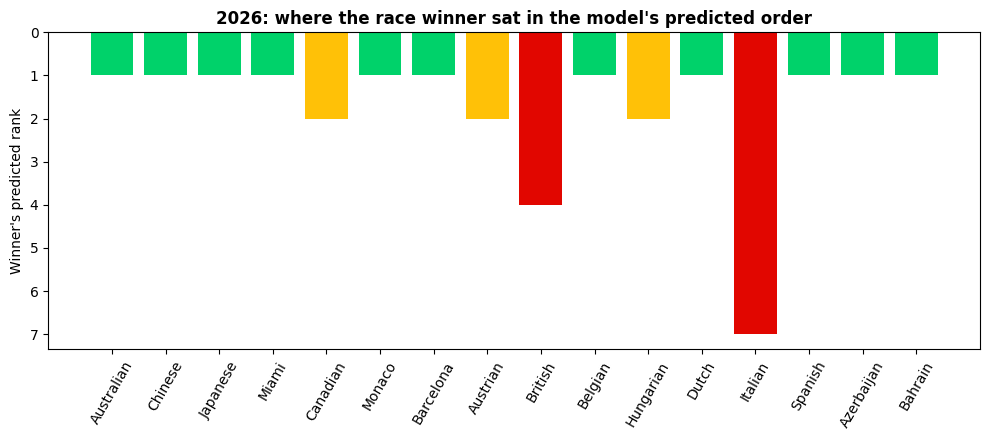

In [3]:
# Race by race: where did the actual winner sit in our predicted order?
per_race = (
    test.drop_duplicates("Round").set_index("Round")[["EventName"]]
    .join(lr_winner_rank.rename("winner_predicted_rank"))
)
print(per_race.to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#00D26A" if r == 1 else "#FFC107" if r <= 3 else "#E10600" for r in per_race["winner_predicted_rank"]]
ax.bar(per_race["EventName"].str.replace(" Grand Prix", ""), per_race["winner_predicted_rank"], color=colors)
ax.set_ylabel("Winner's predicted rank")
ax.set_title("2026: where the race winner sat in the model's predicted order", fontweight="bold")
ax.tick_params(axis="x", rotation=60)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_2026_winner_rank.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings

- The RMSE advantage over the pole baseline **survives the regulation reset** at roughly the same size as on the 2025 holdout — the qualifying and form features are regulation-agnostic.
- Absolute errors are higher for *both* the model and the baseline: a 22-car grid and a new rulebook make races less predictable overall.
- Rows with no form history (Cadillac's first race, rookies' debuts) are excluded here, as in earlier validation notebooks.